In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('malicious_phish.csv')

print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
                                                 url        type
0                                   br-icloud.com.br    phishing
1                mp3raid.com/music/krizz_kaliko.html      benign
2                    bopsecrets.org/rexroth/cr/1.htm      benign
3  http://www.garage-pirenne.be/index.php?option=...  defacement
4  http://adventure-nicaragua.net/index.php?optio...  defacement


In [3]:
print("\nDataset Info (Rows, Columns, and Data Types):")
df.info()


Dataset Info (Rows, Columns, and Data Types):
<class 'pandas.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   url     651191 non-null  str  
 1   type    651191 non-null  str  
dtypes: str(2)
memory usage: 51.6 MB



Exact counts for each URL type:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64


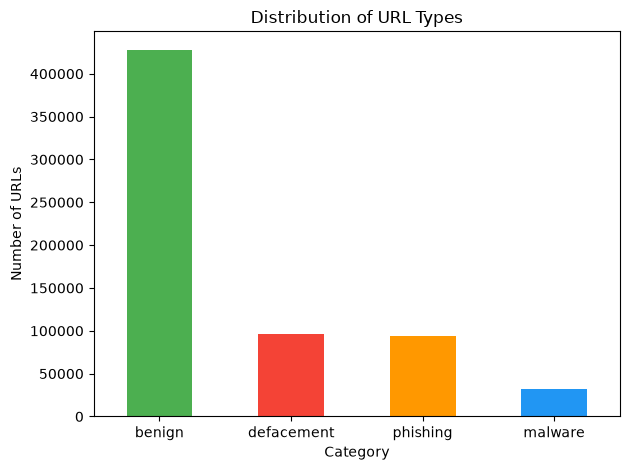

In [4]:
# Count how many of each URL type exist
class_counts = df['type'].value_counts()
print("\nExact counts for each URL type:")
print(class_counts)

# Create a bar chart to visualize the balance
class_counts.plot(kind='bar', color=['#4CAF50', '#F44336', '#FF9800', '#2196F3'])
plt.title('Distribution of URL Types')
plt.xlabel('Category')
plt.ylabel('Number of URLs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
df_binary = df.copy()

# Replace the specific attack types with a simple 'malicious' label
df_binary['type'] = df_binary['type'].replace({'defacement': 'malicious', 
                                               'phishing': 'malicious', 
                                               'malware': 'malicious'})

new_counts = df_binary['type'].value_counts()
print(new_counts)

type
benign       428103
malicious    223088
Name: count, dtype: int64


In [6]:
# Separate the two classes into their own DataFrames
benign_urls = df_binary[df_binary['type'] == 'benign']
malicious_urls = df_binary[df_binary['type'] == 'malicious']

malicious_count = len(malicious_urls)

# Randomly sample the benign URLs to match the malicious count
# random_state=42 ensures one gets the exact same random selection if you run it again
benign_sampled = benign_urls.sample(n=malicious_count, random_state=42)

# Combine the sampled benign URLs with the malicious URLs
balanced_df = pd.concat([benign_sampled, malicious_urls])

# Shuffle the new combined dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify the final distribution
print("New perfectly balanced distribution:")
print(balanced_df['type'].value_counts())

New perfectly balanced distribution:
type
benign       223088
malicious    223088
Name: count, dtype: int64


In [7]:
import urllib.parse
import re
import pandas as pd

def extract_lexical_features(url):
    # Ensures the input is treated as a string to prevent errors with missing or numerical data
    url_str = str(url)
    
    if not url_str.startswith('http'):
        url_str = 'http://' + url_str
        
    features = {}
    
    # Calculates general string metrics first, as these work even on corrupted data
    features['url_length'] = len(url_str)
    features['num_digits'] = sum(c.isdigit() for c in url_str)
    features['num_special_chars'] = sum(1 for c in url_str if c in ['@', '?', '-', '=', '.', '_'])
    
    suspicious_keywords = ['login', 'secure', 'account', 'update', 'admin', 'verify']
    features['num_suspicious_words'] = sum(1 for word in suspicious_keywords if word in url_str.lower())
    
    try:
        # Attempts to parse the URL structure safely
        parsed = urllib.parse.urlparse(url_str)
        domain = parsed.netloc
        path = parsed.path
        
        features['domain_length'] = len(domain)
        features['path_length'] = len(path)
        
        ip_pattern = re.compile(r'\b(?:\d{1,3}\.){3}\d{1,3}\b')
        features['has_ip'] = 1 if ip_pattern.search(domain) else 0
        
    except ValueError:
        # Assigns default zero values for domain-specific metrics if the URL string 
        # contains corrupted characters that cause urllib to fail
        features['domain_length'] = 0
        features['path_length'] = 0
        features['has_ip'] = 0
        
    return features

print("Extracting features... This might take a minute.")
extracted_data = [extract_lexical_features(url) for url in balanced_df['url']]

features_df = pd.DataFrame(extracted_data)
final_df = pd.concat([balanced_df, features_df], axis=1)

print("\nFeature extraction complete. First 5 rows of the new numerical data:")
print(final_df.head())

Extracting features... This might take a minute.

Feature extraction complete. First 5 rows of the new numerical data:
                                                 url       type  url_length  \
0                                     asamcgill.com/     benign          21   
1  http://www.bogdanobradovic.com/t3-assets/js/20...  malicious          63   
2  http://noticias.uol.com.br/tabloide/ultimas-no...     benign         153   
3      manta.com/c/mt4crnc/sue-kelly-dermatology-llc     benign          52   
4  ofmenandangels.blogspot.com/2009/02/vince-azzo...     benign          63   

   num_digits  num_special_chars  num_suspicious_words  domain_length  \
0           0                  1                     0             13   
1           5                  4                     0             23   
2           8                 17                     0             19   
3           1                  4                     0              9   
4           6                  4         

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# The feature columns created in the previous step are isolated as the 'X' matrix
feature_columns = ['url_length', 'domain_length', 'path_length', 'num_digits', 
                   'num_special_chars', 'has_ip', 'num_suspicious_words']
X = final_df[feature_columns]

# The text labels ('benign' and 'malicious') are mapped to binary integers (0 and 1) 
# because machine learning models require numerical targets
y = final_df['type'].map({'benign': 0, 'malicious': 1})

# The dataset is divided, keeping 80% of the rows for training the algorithm 
# and holding back 20% to test how well it performs on URLs it has never seen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# A Random Forest model is instantiated with 100 decision trees
# n_jobs=-1 instructs Scikit-Learn to utilize all available CPU cores for faster processing
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training the Random Forest model...")
# The algorithm examines the training features and learns the patterns associated with malicious URLs
rf_model.fit(X_train, y_train)
print("Model training complete!")

Training data shape: (356940, 7)
Testing data shape: (89236, 7)
Training the Random Forest model...
Model training complete!


Overall Accuracy: 84.28%

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.84      0.85      0.84     44442
   Malicious       0.85      0.84      0.84     44794

    accuracy                           0.84     89236
   macro avg       0.84      0.84      0.84     89236
weighted avg       0.84      0.84      0.84     89236



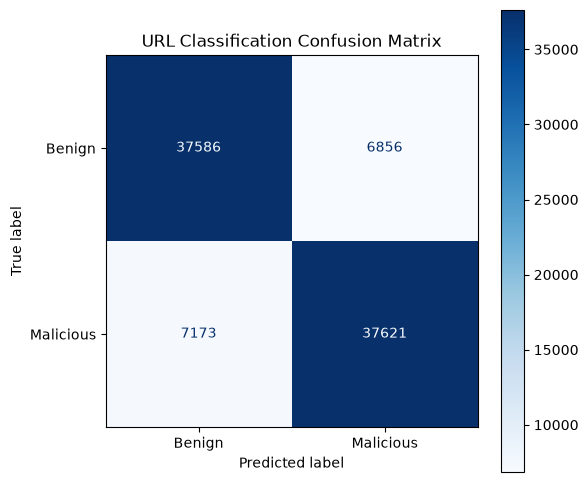

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Generates predictions on the unseen test partition
y_pred = rf_model.predict(X_test)

# Calculates the overall baseline accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

# Displays precision, recall, and f1-score for both benign (0) and malicious (1) classes
# Precision measures how many of the flagged URLs were actually malicious
# Recall measures how many of the actual malicious URLs the model managed to catch
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malicious']))

# Computes the confusion matrix to inspect true vs false predictions directly
cm = confusion_matrix(y_test, y_pred)

# Renders the confusion matrix visual
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malicious'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('URL Classification Confusion Matrix')
plt.show()

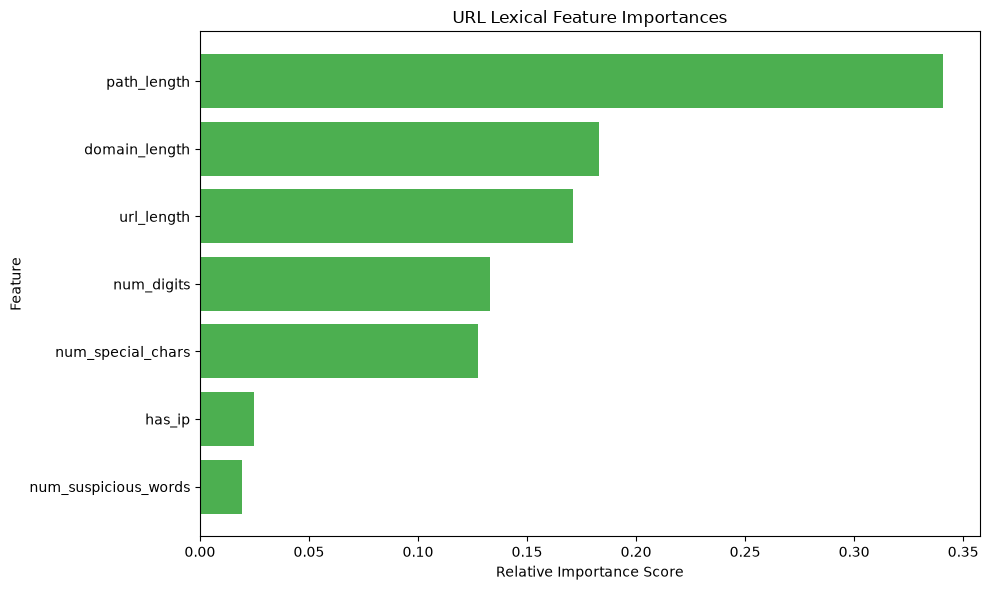

Exact Feature Importance Scores:
             Feature  Importance
         path_length    0.340676
       domain_length    0.183182
          url_length    0.170917
          num_digits    0.133222
   num_special_chars    0.127656
              has_ip    0.024987
num_suspicious_words    0.019359


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Extracts the mathematical importance scores generated by the Random Forest during training
importances = rf_model.feature_importances_

# Binds the raw numerical scores to their corresponding feature names for readability
importance_df = pd.DataFrame({
    'Feature': feature_columns, 
    'Importance': importances
})

# Sorts the DataFrame so the most influential metrics appear at the top
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Renders a horizontal bar chart to visualize the relative weight of each feature
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#4CAF50')
plt.gca().invert_yaxis()  # Reverses the y-axis so the highest score is at the top
plt.title('URL Lexical Feature Importances')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Prints the exact scores for detailed inspection
print("Exact Feature Importance Scores:")
print(importance_df.to_string(index=False))

In [11]:
import urllib.parse
import re
import math
from collections import Counter
import pandas as pd

# Calculates the Shannon entropy (randomness) of a given text string
def calculate_entropy(text):
    if not text:
        return 0
    # Counts the frequency of each character
    counts = Counter(text)
    length = len(text)
    # Applies the Shannon entropy formula: H(X) = -sum(p(x) * log2(p(x)))
    entropy = -sum((count / length) * math.log2(count / length) for count in counts.values())
    return entropy

def extract_lexical_features_v2(url):
    url_str = str(url)
    if not url_str.startswith('http'):
        url_str = 'http://' + url_str
        
    features = {}
    
    features['url_length'] = len(url_str)
    features['num_digits'] = sum(c.isdigit() for c in url_str)
    features['num_special_chars'] = sum(1 for c in url_str if c in ['@', '?', '-', '=', '.', '_'])
    
    suspicious_keywords = ['login', 'secure', 'account', 'update', 'admin', 'verify']
    features['num_suspicious_words'] = sum(1 for word in suspicious_keywords if word in url_str.lower())
    
    try:
        parsed = urllib.parse.urlparse(url_str)
        domain = parsed.netloc
        path = parsed.path
        
        features['domain_length'] = len(domain)
        features['path_length'] = len(path)
        
        # 1. Calculates how random or algorithmic the domain name appears
        features['domain_entropy'] = calculate_entropy(domain)
        
        # 2. Isolates the Top-Level Domain (TLD) by splitting at the dots
        domain_parts = domain.split('.')
        tld = domain_parts[-1] if len(domain_parts) > 1 else ''
        
        features['tld_length'] = len(tld)
        
        # Flags TLDs historically favored by attackers due to low cost or weak registration rules
        suspicious_tlds = ['xyz', 'top', 'pw', 'tk', 'cn', 'ru', 'cc', 'biz', 'info', 'su']
        features['is_suspicious_tld'] = 1 if tld.lower() in suspicious_tlds else 0
        
        ip_pattern = re.compile(r'\b(?:\d{1,3}\.){3}\d{1,3}\b')
        features['has_ip'] = 1 if ip_pattern.search(domain) else 0
        
    except ValueError:
        features['domain_length'] = 0
        features['path_length'] = 0
        features['domain_entropy'] = 0
        features['tld_length'] = 0
        features['is_suspicious_tld'] = 0
        features['has_ip'] = 0
        
    return features

print("Extracting updated features (this will take slightly longer due to entropy math)...")
extracted_data_v2 = [extract_lexical_features_v2(url) for url in balanced_df['url']]

features_df_v2 = pd.DataFrame(extracted_data_v2)
final_df_v2 = pd.concat([balanced_df, features_df_v2], axis=1)

print("\nUpdated extraction complete. First 5 rows:")
print(final_df_v2.head())

Extracting updated features (this will take slightly longer due to entropy math)...

Updated extraction complete. First 5 rows:
                                                 url       type  url_length  \
0                                     asamcgill.com/     benign          21   
1  http://www.bogdanobradovic.com/t3-assets/js/20...  malicious          63   
2  http://noticias.uol.com.br/tabloide/ultimas-no...     benign         153   
3      manta.com/c/mt4crnc/sue-kelly-dermatology-llc     benign          52   
4  ofmenandangels.blogspot.com/2009/02/vince-azzo...     benign          63   

   num_digits  num_special_chars  num_suspicious_words  domain_length  \
0           0                  1                     0             13   
1           5                  4                     0             23   
2           8                 17                     0             19   
3           1                  4                     0              9   
4           6                  4

In [12]:
feature_columns = ['url_length', 'domain_length', 'path_length', 'num_digits', 
                   'num_special_chars', 'has_ip', 'num_suspicious_words',
                   'domain_entropy', 'tld_length', 'is_suspicious_tld']

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# The feature list is updated to include the 3 newly engineered metrics
feature_columns_v2 = ['url_length', 'domain_length', 'path_length', 'num_digits', 
                      'num_special_chars', 'has_ip', 'num_suspicious_words',
                      'domain_entropy', 'tld_length', 'is_suspicious_tld']

# The X matrix is built using the updated DataFrame
X_v2 = final_df_v2[feature_columns_v2]
y_v2 = final_df_v2['type'].map({'benign': 0, 'malicious': 1})

# The data is split again using the same 80/20 ratio and random state for a fair comparison
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

# A fresh Random Forest model is instantiated to ensure no data from the previous run leaks over
rf_model_v2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training updated model with 10 features...")
rf_model_v2.fit(X_train_v2, y_train_v2)

# Predictions are generated on the new test partition
y_pred_v2 = rf_model_v2.predict(X_test_v2)
accuracy_v2 = accuracy_score(y_test_v2, y_pred_v2)

# The new scores are printed alongside a reminder of the previous baseline
print(f"\nPrevious Accuracy: 84.28%")
print(f"New Overall Accuracy: {accuracy_v2 * 100:.2f}%\n")

print("New Detailed Classification Report:")
print(classification_report(y_test_v2, y_pred_v2, target_names=['Benign', 'Malicious']))

Training updated model with 10 features...

Previous Accuracy: 84.28%
New Overall Accuracy: 89.13%

New Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.89      0.89      0.89     44442
   Malicious       0.89      0.89      0.89     44794

    accuracy                           0.89     89236
   macro avg       0.89      0.89      0.89     89236
weighted avg       0.89      0.89      0.89     89236



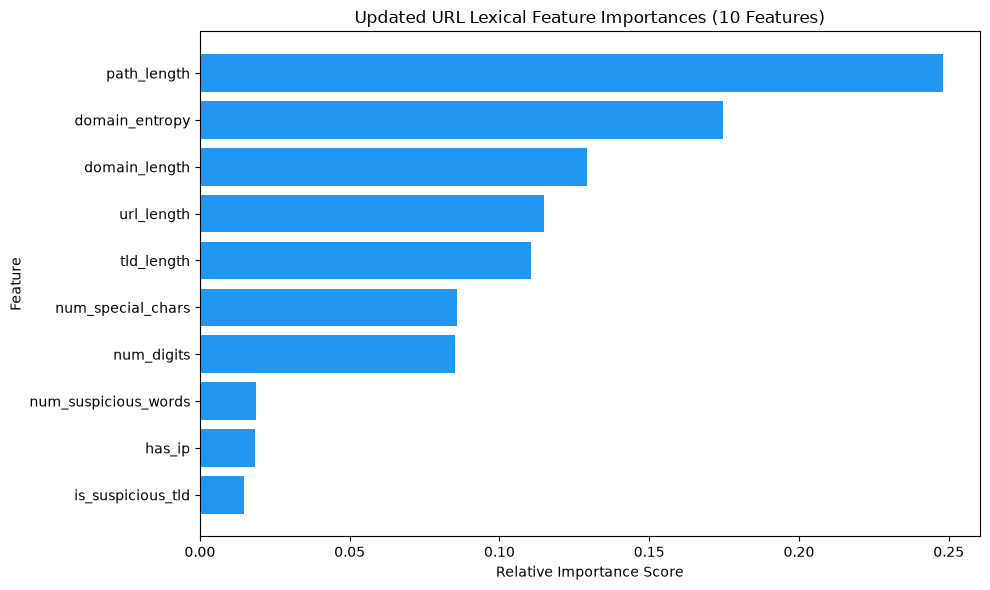

Exact Updated Feature Importance Scores:
             Feature  Importance
         path_length    0.248034
      domain_entropy    0.174553
       domain_length    0.129322
          url_length    0.114725
          tld_length    0.110527
   num_special_chars    0.085930
          num_digits    0.085034
num_suspicious_words    0.018669
              has_ip    0.018378
   is_suspicious_tld    0.014827


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Extracts the mathematical importance scores from the newly trained 10-feature model
importances_v2 = rf_model_v2.feature_importances_

# Binds the new numerical scores to the updated list of 10 feature names
importance_df_v2 = pd.DataFrame({
    'Feature': feature_columns_v2, 
    'Importance': importances_v2
})

# Sorts the DataFrame to bring the most influential metrics to the top
importance_df_v2 = importance_df_v2.sort_values(by='Importance', ascending=False)

# Renders the updated horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(importance_df_v2['Feature'], importance_df_v2['Importance'], color='#2196F3')
plt.gca().invert_yaxis()
plt.title('Updated URL Lexical Feature Importances (10 Features)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Prints the exact scores for a detailed breakdown
print("Exact Updated Feature Importance Scores:")
print(importance_df_v2.to_string(index=False))

In [15]:
import urllib.parse
import re
import math
from collections import Counter
import pandas as pd

def calculate_entropy(text):
    if not text:
        return 0
    counts = Counter(text)
    length = len(text)
    return -sum((count / length) * math.log2(count / length) for count in counts.values())

def extract_lexical_features_v3(url):
    url_str = str(url)
    if not url_str.startswith('http'):
        url_str = 'http://' + url_str
        
    features = {}
    
    # Base structural features
    features['url_length'] = len(url_str)
    features['num_digits'] = sum(c.isdigit() for c in url_str)
    features['num_special_chars'] = sum(1 for c in url_str if c in ['@', '?', '-', '=', '.', '_'])
    
    # Evasion Metric 1: Counts the percentage signs used in URL encoding (e.g., %20, %3C)
    features['num_encoded_chars'] = url_str.count('%')
    
    suspicious_keywords = ['login', 'secure', 'account', 'update', 'admin', 'verify']
    features['num_suspicious_words'] = sum(1 for word in suspicious_keywords if word in url_str.lower())
    
    try:
        parsed = urllib.parse.urlparse(url_str)
        domain = parsed.netloc
        path = parsed.path
        
        features['domain_length'] = len(domain)
        features['path_length'] = len(path)
        
        # Evasion Metric 2: Counts the slashes in the path to measure directory depth
        # A higher count often indicates a payload buried deep in nested folders
        features['directory_depth'] = path.count('/')
        
        # Evasion Metric 3: Counts the dots in the domain to measure subdomain complexity
        # Attackers string multiple subdomains together to spoof legitimate services
        features['subdomain_count'] = domain.count('.')
        
        features['domain_entropy'] = calculate_entropy(domain)
        
        domain_parts = domain.split('.')
        tld = domain_parts[-1] if len(domain_parts) > 1 else ''
        features['tld_length'] = len(tld)
        
        suspicious_tlds = ['xyz', 'top', 'pw', 'tk', 'cn', 'ru', 'cc', 'biz', 'info', 'su']
        features['is_suspicious_tld'] = 1 if tld.lower() in suspicious_tlds else 0
        
        ip_pattern = re.compile(r'\b(?:\d{1,3}\.){3}\d{1,3}\b')
        features['has_ip'] = 1 if ip_pattern.search(domain) else 0
        
    except ValueError:
        features['domain_length'] = 0
        features['path_length'] = 0
        features['directory_depth'] = 0
        features['subdomain_count'] = 0
        features['domain_entropy'] = 0
        features['tld_length'] = 0
        features['is_suspicious_tld'] = 0
        features['has_ip'] = 0
        
    return features

print("Extracting v3 features (13 total metrics)...")
extracted_data_v3 = [extract_lexical_features_v3(url) for url in balanced_df['url']]

features_df_v3 = pd.DataFrame(extracted_data_v3)
final_df_v3 = pd.concat([balanced_df, features_df_v3], axis=1)

print("\nUpdated extraction complete. Ready for training.")

Extracting v3 features (13 total metrics)...

Updated extraction complete. Ready for training.


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# The feature list now includes the 3 evasion metrics
feature_columns_v3 = ['url_length', 'domain_length', 'path_length', 'num_digits', 
                      'num_special_chars', 'has_ip', 'num_suspicious_words',
                      'domain_entropy', 'tld_length', 'is_suspicious_tld',
                      'num_encoded_chars', 'directory_depth', 'subdomain_count']

X_v3 = final_df_v3[feature_columns_v3]
y_v3 = final_df_v3['type'].map({'benign': 0, 'malicious': 1})

# Splitting using the exact same random_state ensures an apples-to-apples comparison
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(X_v3, y_v3, test_size=0.2, random_state=42)

rf_model_v3 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training updated model with 13 features...")
rf_model_v3.fit(X_train_v3, y_train_v3)

y_pred_v3 = rf_model_v3.predict(X_test_v3)
accuracy_v3 = accuracy_score(y_test_v3, y_pred_v3)

print(f"\nPrevious Accuracy (10 features): 89.13%")
print(f"New Overall Accuracy (13 features): {accuracy_v3 * 100:.2f}%\n")

print("New Detailed Classification Report:")
print(classification_report(y_test_v3, y_pred_v3, target_names=['Benign', 'Malicious']))

Training updated model with 13 features...

Previous Accuracy (10 features): 89.13%
New Overall Accuracy (13 features): 91.72%

New Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.92      0.92     44442
   Malicious       0.92      0.92      0.92     44794

    accuracy                           0.92     89236
   macro avg       0.92      0.92      0.92     89236
weighted avg       0.92      0.92      0.92     89236



In [17]:
from sklearn.model_selection import RandomizedSearchCV

# Define the "menu" of settings for the model to try
param_dist = {
    'n_estimators': [100, 200, 300],       # Number of decision trees
    'max_depth': [None, 10, 20, 30],       # How deep each tree can grow
    'min_samples_split': [2, 5, 10],       # Minimum rows required to split a node
    'min_samples_leaf': [1, 2, 4]          # Minimum rows required at the very end of a branch
}

# Initialize a fresh base model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Set up the randomized search
# n_iter=10 tells it to test 10 random combinations from our grid above
# cv=3 means it validates each combination 3 times to ensure the score isn't a fluke
random_search = RandomizedSearchCV(estimator=rf_base, param_distributions=param_dist, 
                                   n_iter=10, cv=3, random_state=42, n_jobs=-1, verbose=2)

print("Starting hyperparameter tuning... You might hear your cooling fans spin up!")
random_search.fit(X_train_v3, y_train_v3)

print("\nTuning complete! Best parameters found:")
print(random_search.best_params_)

# Extract the absolute best model from the search
best_rf_model = random_search.best_estimator_

# Test the optimized model on the unseen holdout data
from sklearn.metrics import accuracy_score
y_pred_optimized = best_rf_model.predict(X_test_v3)
accuracy_optimized = accuracy_score(y_test_v3, y_pred_optimized)

print(f"\nOptimized Accuracy: {accuracy_optimized * 100:.2f}%")

Starting hyperparameter tuning... You might hear your cooling fans spin up!
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Tuning complete! Best parameters found:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}

Optimized Accuracy: 91.94%


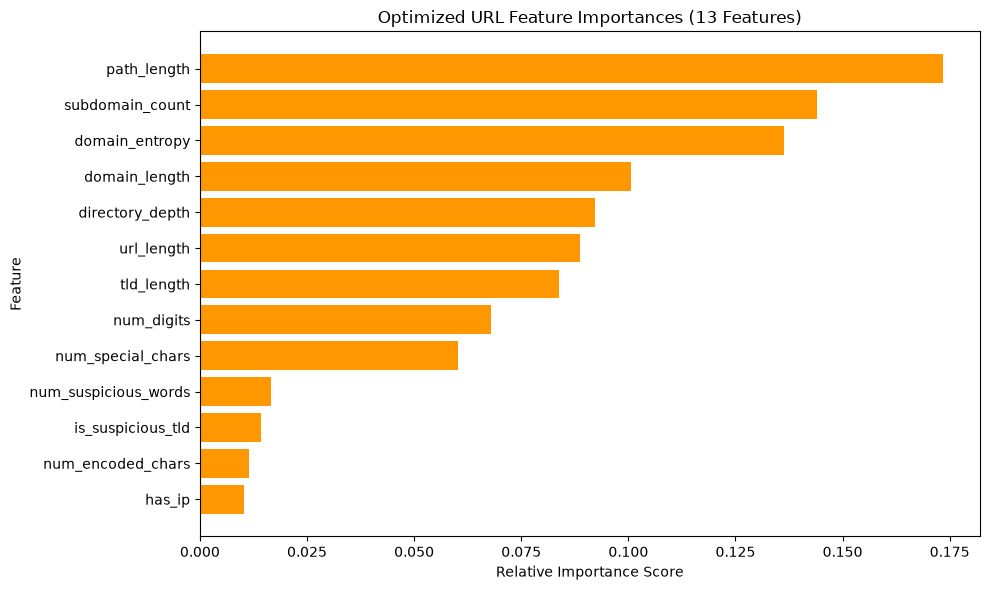

Exact Optimized Feature Importance Scores:
             Feature  Importance
         path_length    0.173400
     subdomain_count    0.144017
      domain_entropy    0.136283
       domain_length    0.100580
     directory_depth    0.092276
          url_length    0.088650
          tld_length    0.083922
          num_digits    0.067888
   num_special_chars    0.060328
num_suspicious_words    0.016509
   is_suspicious_tld    0.014358
   num_encoded_chars    0.011448
              has_ip    0.010341


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Extracts the importance weights directly from the newly tuned, optimal model
importances_optimized = best_rf_model.feature_importances_

# Maps the scores to our list of 13 features
importance_df_optimized = pd.DataFrame({
    'Feature': feature_columns_v3, 
    'Importance': importances_optimized
})

# Sorts the metrics to highlight the most dominant decision factors
importance_df_optimized = importance_df_optimized.sort_values(by='Importance', ascending=False)

# Renders the final bar chart, using a new color to distinguish this optimized version
plt.figure(figsize=(10, 6))
plt.barh(importance_df_optimized['Feature'], importance_df_optimized['Importance'], color='#FF9800')
plt.gca().invert_yaxis()
plt.title('Optimized URL Feature Importances (13 Features)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Prints the exact scores
print("Exact Optimized Feature Importance Scores:")
print(importance_df_optimized.to_string(index=False))

In [19]:
import joblib

# Saves the tuned model for the API to use
joblib.dump(best_rf_model, 'url_classifier_v3.joblib')
print("Model saved to disk!")

Model saved to disk!
